## 2. [LO 1, LO 2, LO 3 & LO 4, 30 poin] DJ Patil dikenal sebagai data scientist yang pertama kali. Tugasnya adalah memvisualisasi maha data untuk diubah menjadi informasi yang bermanfaat. Ia ingin melakukan Dimension Reduction dari dua kelas citra dengan menggunakan algoritma Autoencoder secara optimal. Anda diminta untuk membantu DJ Patil dalam melakukan tugas ini.
Video penjelasan:  https://drive.google.com/drive/folders/1QrVhhmqQCJuAX4GiaGiQDSW5Pp9wb_CK?usp=sharing

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from skimage.metrics import structural_similarity as ssim

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import zipfile

zip_path = "/content/oplane.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

saya menggunakan dataset plane overhead untuk menjawab soal nomor 2 dan menggabungkan datasetnya secara manual yaitu dengan cara memindahkan dataset plane dari folder train dan test ke folder baru yang bernama 'oplane'. Tujuannya untuk memudahkan loading dataset.

## 2a. [LO 3, LO 4, 5 poin] Lakukan loading dan scaling data serta tampilkan contoh data yang digunakan. Kemudian pisahkan dataset menjadi 80% training set, 10% validation set dan 10% test set.

In [ ]:
DATA_DIR = Path("/content/oplane")

IMG_SIZE  = (28, 28)
IMG_EXT   = {".png", ".jpg", ".jpeg", ".bmp"}

def load_images_from_dir(directory: Path) -> list:
    images = []
    for fpath in sorted(directory.iterdir()):
        if fpath.suffix.lower() in IMG_EXT:
            img = Image.open(fpath).convert("L").resize(IMG_SIZE)
            images.append(np.array(img, dtype=np.uint8))
    return images

all_images = load_images_from_dir(DATA_DIR)
all_images = np.array(all_images, dtype=np.float32)

print(f"Total gambar: {len(all_images)}")
print(f"Shape data: {all_images.shape}")

Total gambar: 1000
Shape data: (1000, 28, 28)


In [ ]:
all_images_scaled = all_images / 255.0
print(f"Pixel min : {all_images_scaled.min():.4f}")
print(f"Pixel max : {all_images_scaled.max():.4f}")
print(f"Data type : {all_images_scaled.dtype}")

Pixel min : 0.0000
Pixel max : 1.0000
Data type : float32


In [ ]:
X_trainval, X_test = train_test_split(
    all_images_scaled, test_size=0.10, random_state=SEED, shuffle=True
)

X_train, X_val = train_test_split(
    X_trainval, test_size=(1/9), random_state=SEED, shuffle=True
)

print(f"Training set: {X_train.shape[0]}")
print(f"Validation set: {X_val.shape[0]}")
print(f"Test set: {X_test.shape[0]}")

Training set: 800
Validation set: 100
Test set: 100


In [ ]:
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print(f"X_train shape : {X_train.shape}")
print(f"X_val   shape : {X_val.shape}")
print(f"X_test  shape : {X_test.shape}")

X_train shape : (800, 28, 28, 1)
X_val   shape : (100, 28, 28, 1)
X_test  shape : (100, 28, 28, 1)


### Visualisasi contoh data

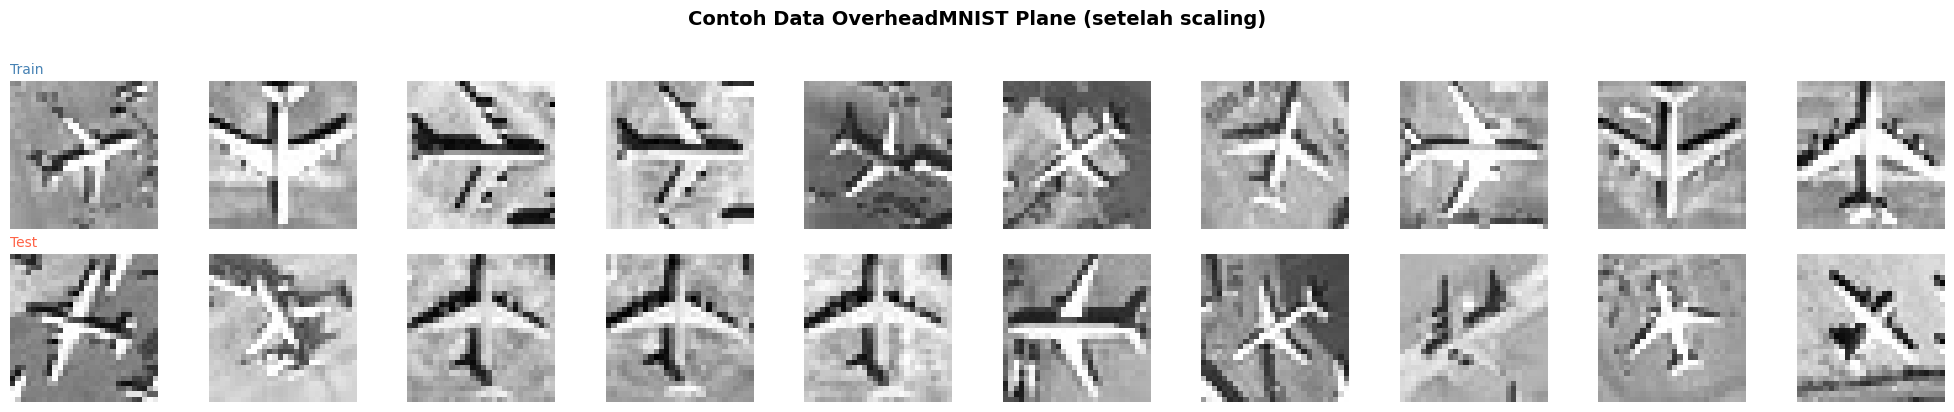

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
fig.suptitle("Contoh Data OverheadMNIST Plane (setelah scaling)",
             fontsize=14, fontweight="bold", y=1.02)

for i in range(10):
    axes[0, i].imshow(X_train[i, :, :, 0], cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Train", loc="left", fontsize=10, color="steelblue")

    axes[1, i].imshow(X_test[i, :, :, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Test", loc="left", fontsize=10, color="tomato")

plt.tight_layout()
plt.savefig("sample_data.png", dpi=120, bbox_inches="tight")
plt.show()

### Baseline Autoencoder Architecture

Encoder bertugas melakukan dimension reduction dari citra berukuran 28×28 (784 piksel) menjadi latent vector berukuran 128 menggunakan kombinasi Conv2D, MaxPooling2D, Flatten, dan Dense. Conv2D digunakan untuk mengekstraksi fitur citra, sedangkan MaxPooling2D mengurangi dimensi feature map tanpa menghilangkan informasi penting.

Decoder kemudian merekonstruksi kembali latent vector menjadi citra berukuran 28×28 melalui Dense, Reshape, UpSampling2D, dan Conv2D. Layer terakhir menggunakan aktivasi sigmoid agar nilai output berada pada rentang 0–1, sesuai dengan hasil normalisasi data.

Encoder dan decoder digabungkan menjadi satu model autoencoder, kemudian dikompilasi menggunakan optimizer Adam (learning rate = 0.001) dan loss function Mean Squared Error (MSE) karena tujuan model adalah meminimalkan perbedaan antara citra asli dan citra hasil rekonstruksi.

In [ ]:
def build_encoder(latent_dim: int = 128):
    inp = layers.Input(shape=(28, 28, 1), name="encoder_input")
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same",
                      name="enc_conv")(inp)
    x = layers.MaxPooling2D((2, 2), name="enc_maxpool")(x)
    x = layers.Flatten(name="enc_flatten")(x)
    latent = layers.Dense(latent_dim, activation="relu", name="latent")(x)

    return models.Model(inp, latent, name="Encoder")


def build_decoder(latent_dim: int = 128):
    inp = layers.Input(shape=(latent_dim,), name="decoder_input")
    x = layers.Dense(14 * 14 * 32, name="dec_dense")(inp)
    x = layers.Reshape((14, 14, 32), name="dec_reshape")(x)
    x = layers.UpSampling2D((2, 2), name="dec_upsample")(x)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same",
                      name="dec_conv_relu")(x)
    out = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same",
                        name="dec_conv_sigmoid")(x)

    return models.Model(inp, out, name="Decoder")


LATENT_DIM = 128

encoder = build_encoder(LATENT_DIM)
decoder = build_decoder(LATENT_DIM)

ae_input  = layers.Input(shape=(28, 28, 1), name="autoencoder_input")
ae_output = decoder(encoder(ae_input))
autoencoder = models.Model(ae_input, ae_output, name="Baseline_Autoencoder")

autoencoder.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mse"
)

encoder.summary()
decoder.summary()
autoencoder.summary()

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_maxpool (MaxPooling2D)      │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_flatten (Flatten)           │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 128)            │       802,944 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 803,264 (3.06 MB)

 Trainable params: 803,264 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "Baseline_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 128)            │       803,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 28, 28, 1)      │       818,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,621,889 (6.19 MB)

 Trainable params: 1,621,889 (6.19 MB)

 Non-trainable params: 0 (0.00 B)

### Training

In [ ]:
EPOCHS     = 50
BATCH_SIZE = 64

cb_list = [
    callbacks.EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        "best_baseline_autoencoder.keras",
        monitor="val_loss", save_best_only=True, verbose=0
    )
]

history = autoencoder.fit(
    X_train, X_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, X_val),
    callbacks=cb_list,
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - loss: 0.0544 - val_loss: 0.0520 - learning_rate: 0.0010
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0487 - val_loss: 0.0513 - learning_rate: 0.0010
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0470 - val_loss: 0.0483 - learning_rate: 0.0010
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0438 - val_loss: 0.0450 - learning_rate: 0.0010
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0406 - val_loss: 0.0431 - learning_rate: 0.0010
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0385 - val_loss: 0.0412 - learning_rate: 0.0010
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0367 - val_loss: 0.0400 - learning_rate: 0.0010
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0352 - val_loss: 0.0384 - learning_rate: 0.0010
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0333 - val_loss: 0.0360 - learning_rate: 0.0010
Epoch 10/50
13/13 

### Plot training

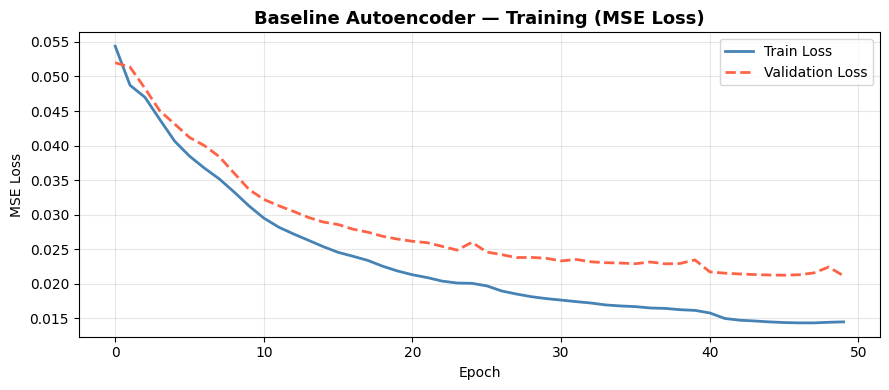

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(history.history["loss"],     label="Train Loss",      color="steelblue",  lw=2)
ax.plot(history.history["val_loss"], label="Validation Loss", color="tomato",     lw=2, linestyle="--")
ax.set_title("Baseline Autoencoder — Training (MSE Loss)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=120, bbox_inches="tight")
plt.show()

Dari grafik terlihat bahwa baik training loss maupun validation loss sama-sama mengalami penurunan selama proses training. Hal ini menunjukkan bahwa model secara bertahap mampu memperbaiki kualitas rekonstruksi citra.

Kedua kurva memiliki pola yang relatif searah dengan selisih yang tidak terlalu besar. Kondisi ini menunjukkan bahwa model masih mampu melakukan generalisasi terhadap data validasi dan belum mengalami overfitting yang signifikan.

In [ ]:
X_test_reconstructed = autoencoder.predict(X_test, batch_size=64, verbose=0)
print(f"Rekonstruksi selesai. Output shape: {X_test_reconstructed.shape}")

Rekonstruksi selesai. Output shape: (100, 28, 28, 1)


### Evaluasi SSIM

In [ ]:
def compute_ssim_scores(originals: np.ndarray, reconstructed: np.ndarray) -> np.ndarray:
    scores = []
    for orig, recon in zip(originals, reconstructed):
        orig_2d  = orig[:, :, 0]
        recon_2d = recon[:, :, 0]
        score = ssim(orig_2d, recon_2d, data_range=1.0)
        scores.append(score)
    return np.array(scores)

ssim_scores = compute_ssim_scores(X_test, X_test_reconstructed)

print(f"SSIM  mean  : {ssim_scores.mean():.4f}")
print(f"SSIM  std   : {ssim_scores.std():.4f}")
print(f"SSIM  min   : {ssim_scores.min():.4f}")
print(f"SSIM  max   : {ssim_scores.max():.4f}")

SSIM  mean  : 0.5811
SSIM  std   : 0.1610
SSIM  min   : 0.2798
SSIM  max   : 0.8449


Rata-rata SSIM sebesar 0.5811 menunjukkan bahwa autoencoder sudah mampu merekonstruksi bentuk umum pesawat, tetapi kualitas rekonstruksinya masih berada pada tingkat sedang. Standar deviasi sebesar 0.1610 artinya, ada gambar yang dapat direkonstruksi dengan sangat baik, ada juga gambar yang sulit dipelajari oleh model.

### Visualisasi Original dan Rekonstruksi

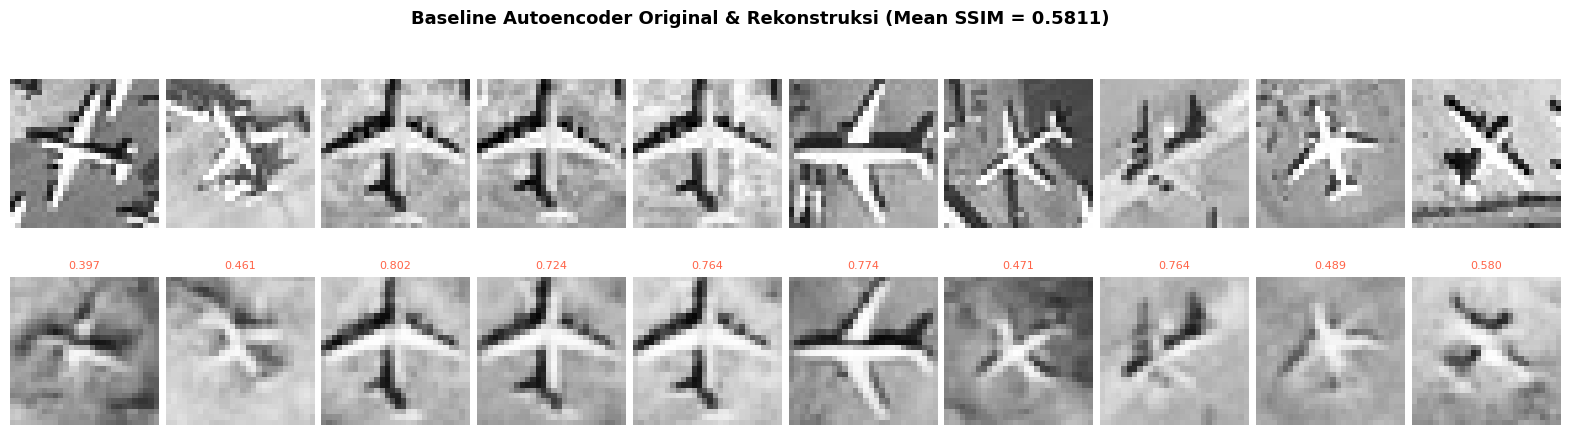

In [ ]:
n_show = 10

fig = plt.figure(figsize=(20, 5))
fig.suptitle(
    f"Baseline Autoencoder Original & Rekonstruksi (Mean SSIM = {ssim_scores.mean():.4f})",
    fontsize=13, fontweight="bold"
)

gs = gridspec.GridSpec(2, n_show, hspace=0.05, wspace=0.05)

for i in range(n_show):
    # Baris atas: original
    ax_orig = fig.add_subplot(gs[0, i])
    ax_orig.imshow(X_test[i, :, :, 0], cmap="gray", vmin=0, vmax=1)
    ax_orig.axis("off")
    if i == 0:
        ax_orig.set_ylabel("Original", fontsize=10, color="steelblue")

    # Baris bawah: rekonstruksi
    ax_recon = fig.add_subplot(gs[1, i])
    ax_recon.imshow(X_test_reconstructed[i, :, :, 0], cmap="gray", vmin=0, vmax=1)
    ax_recon.axis("off")
    ax_recon.set_title(f"{ssim_scores[i]:.3f}", fontsize=8, color="tomato")
    if i == 0:
        ax_recon.set_ylabel("Rekon.", fontsize=10, color="tomato")

plt.savefig("reconstruction_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

angka di bawah tiap gambar = SSIM individual

## 2c. [LO 1, LO 2, LO 3, LO 4, 10 poin] Setelah mengetahui hasil dari nomor (2b), modifikasi arsitektur Autoencoder di atas agar mendapatkan representasi Dimension Reduction yang optimal dengan membandingkan hasil Structural Similarity Index (SSIM) nya. Dan selanjutnya lakukan proses tuning hyperparameter agar unjuk kerjanya meningkat. Berikan alasan mengapa modifikasi arsitektur dan metode tuning hyperparameter kalian lebih baik.

 Strategi: arsitektur tetap "tipis" seperti baseline (cocok untuk dataset kecil
           hanya 800 sampel), tapi diperbaiki dengan:
   v2 → SSIM loss (bukan pure MSE) + L2 regularizer kecil + lebih banyak filter
  v3 → v2 + cosine-decay LR + SSIM-weighted loss composite


In [ ]:
def compute_ssim_scores(X_true, X_pred):
    scores = []
    for i in range(len(X_true)):
        s = ssim(
            X_true[i].squeeze(), X_pred[i].squeeze(),
            data_range=1.0
        )
        scores.append(s)
    return np.array(scores)


### custom ssim los
Fungsi ssim_loss digunakan sebagai loss utama pada model. Nilai loss dihitung dari 1 − SSIM, sehingga semakin mirip gambar hasil rekonstruksi dengan gambar asli, nilai loss akan semakin kecil.

Selain itu dibuat juga composite_loss, yaitu gabungan antara SSIM Loss dan MSE. Fungsi ini disiapkan sebagai alternatif jika ingin menyeimbangkan kemiripan struktur gambar dan kesalahan piksel. Namun pada implementasi akhir, model menggunakan SSIM Loss sebagai loss function.

In [ ]:
def ssim_loss(y_true, y_pred):
    return 1.0 - tf.reduce_mean(
        tf.image.ssim(y_true, y_pred, max_val=1.0)
    )

def composite_loss(y_true, y_pred, alpha=0.85):
    mse  = tf.reduce_mean(tf.square(y_true - y_pred))
    ssl  = ssim_loss(y_true, y_pred)
    return alpha * ssl + (1.0 - alpha) * mse


### arsitektur v2

Arsitektur v2 masih mempertahankan bentuk dasar autoencoder seperti baseline agar tidak terlalu kompleks untuk dataset yang relatif kecil.

 terdapat beberapa perubahan, yaitu:

- jumlah filter Conv2D ditingkatkan dari 32 menjadi 64 agar fitur yang dipelajari lebih banyak,
- ditambahkan Dense 256 neuron sebelum latent layer supaya proses kompresi menjadi lebih baik,
- ditambahkan L2 Regularization (1e-5) pada Dense layer untuk membantu mengurangi overfitting.
- Loss diganti SSIM loss

In [ ]:
LATENT_DIM = 128

def build_encoder_v2(latent_dim):
    inp = layers.Input(shape=(28, 28, 1), name="enc_input_v2")
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu", name="enc_conv1")(inp)
    x = layers.MaxPooling2D((2, 2), name="enc_pool")(x)
    x = layers.Flatten(name="enc_flatten")(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-5),
                     name="enc_dense_mid")(x)
    z = layers.Dense(latent_dim, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-5),
                     name="enc_latent")(x)

    return models.Model(inp, z, name="Encoder_v2")


def build_decoder_v2(latent_dim):
    inp = layers.Input(shape=(latent_dim,), name="dec_input_v2")
    x = layers.Dense(14 * 14 * 32, activation="relu",
                     name="dec_dense")(inp)
    x = layers.Reshape((14, 14, 32), name="dec_reshape")(x)
    x = layers.UpSampling2D((2, 2), name="dec_upsample")(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu",
                      name="dec_conv_relu")(x)
    out = layers.Conv2D(1, (3, 3), padding="same", activation="sigmoid",
                        name="dec_conv_sigmoid")(x)

    return models.Model(inp, out, name="Decoder_v2")


encoder_v2 = build_encoder_v2(LATENT_DIM)
decoder_v2 = build_decoder_v2(LATENT_DIM)

ae_input_v2  = layers.Input(shape=(28, 28, 1), name="ae_input_v2")
ae_output_v2 = decoder_v2(encoder_v2(ae_input_v2))
autoencoder_v2 = models.Model(ae_input_v2, ae_output_v2, name="Autoencoder_v2")

autoencoder_v2.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=ssim_loss
)

encoder_v2.summary()
decoder_v2.summary()
autoencoder_v2.summary()



Model: "Encoder_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ enc_input_v2 (InputLayer)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool (MaxPooling2D)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_flatten (Flatten)           │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_mid (Dense)           │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_latent (Dense)              │ (None, 128)            │        32,896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,245,056 (12.38 MB)

 Trainable params: 3,245,056 (12.38 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "Autoencoder_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_input_v2 (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_v2 (Functional)         │ (None, 128)            │     3,245,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_v2 (Functional)         │ (None, 28, 28, 1)      │       828,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,073,217 (15.54 MB)

 Trainable params: 4,073,217 (15.54 MB)

 Non-trainable params: 0 (0.00 B)

### training v2

In [ ]:
callbacks_v2 = [
    callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=7,
        min_lr=1e-5, verbose=1
    ),
]

history_v2 = autoencoder_v2.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks_v2,
    verbose=1
)


X_test_recon_v2 = autoencoder_v2.predict(X_test, batch_size=64, verbose=0)
ssim_scores_v2  = compute_ssim_scores(X_test, X_test_recon_v2)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 308ms/step - loss: 0.8580 - val_loss: 0.8420 - learning_rate: 0.0010
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.8088 - val_loss: 0.8236 - learning_rate: 0.0010
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7961 - val_loss: 0.8141 - learning_rate: 0.0010
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7790 - val_loss: 0.7751 - learning_rate: 0.0010
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7220 - val_loss: 0.7213 - learning_rate: 0.0010
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6694 - val_loss: 0.6695 - learning_rate: 0.0010
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6099 - val_loss: 0.6270 - learning_rate: 0.0010
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5580 - val_loss: 0.5803 - learning_rate: 0.0010
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5154 - val_loss: 0.5518 - learning_rate: 0.0010
Epoch 10/

### evaluasi SSIM v2

In [ ]:
print(f"SSIM mean: {ssim_scores_v2.mean():.4f}  (baseline: {ssim_scores.mean():.4f})")
print(f"SSIM std: {ssim_scores_v2.std():.4f}  (baseline: {ssim_scores.std():.4f})")
delta_v2 = ssim_scores_v2.mean() - ssim_scores.mean()
print(f"ΔMean SSIM (v2 − baseline) : {delta_v2:+.4f}  {'Meningkat' if delta_v2 > 0 else 'Menurun'}")

SSIM mean: 0.5919  (baseline: 0.5811)
SSIM std: 0.1647  (baseline: 0.1610)
ΔMean SSIM (v2 − baseline) : +0.0108  Meningkat


Baseline : 0.5811

v2 : 0.5919

Nilai SSIM meningkat sekitar 0.0108, menunjukkan bahwa perubahan arsitektur dan penggunaan SSIM Loss mampu menghasilkan rekonstruksi yang sedikit lebih baik dibanding baseline.

### Arsitektur v3: v2 + Hyperparameter Tuning
- LR      : Cosine Decay dari 3e-4 ke 1e-5 selama 150 epoch
- Epoch   : diperbanyak jadi 150
- Batch   : 32 (gradient update lebih sering)
- Dropout : 5% pada encoder supaya latent space lebih robust

In [ ]:
def build_encoder_v3(latent_dim):
    inp = layers.Input(shape=(28, 28, 1), name="enc_input_v3")
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu",
                      name="enc_conv1")(inp)
    x = layers.MaxPooling2D((2, 2), name="enc_pool")(x)
    x = layers.Flatten(name="enc_flatten")(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-5),
                     name="enc_dense_mid")(x)
    x = layers.Dropout(0.05, name="enc_dropout")(x)
    z = layers.Dense(latent_dim, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-5),
                     name="enc_latent")(x)
    return models.Model(inp, z, name="Encoder_v3")

def build_decoder_v3(latent_dim):
    inp = layers.Input(shape=(latent_dim,), name="dec_input_v3")
    x = layers.Dense(14 * 14 * 32, activation="relu", name="dec_dense")(inp)
    x = layers.Reshape((14, 14, 32), name="dec_reshape")(x)
    x = layers.UpSampling2D((2, 2), name="dec_upsample")(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu",
                      name="dec_conv_relu")(x)
    out = layers.Conv2D(1, (3, 3), padding="same", activation="sigmoid",
                        name="dec_conv_sigmoid")(x)
    return models.Model(inp, out, name="Decoder_v3")

TOTAL_EPOCHS_V3    = 150
STEPS_PER_EPOCH_V3 = len(X_train) // 32

lr_schedule_v3 = CosineDecay(
    initial_learning_rate=3e-4,
    decay_steps=TOTAL_EPOCHS_V3 * STEPS_PER_EPOCH_V3,
    alpha=1e-5 / 3e-4
)

encoder_v3 = build_encoder_v3(LATENT_DIM)
decoder_v3 = build_decoder_v3(LATENT_DIM)

ae_input_v3  = layers.Input(shape=(28, 28, 1), name="ae_input_v3")
ae_output_v3 = decoder_v3(encoder_v3(ae_input_v3))
autoencoder_v3 = models.Model(ae_input_v3, ae_output_v3, name="Autoencoder_v3")

autoencoder_v3.compile(
    optimizer=Adam(learning_rate=lr_schedule_v3),
    loss=ssim_loss
)

autoencoder_v3.summary()

callbacks_v3 = [
    callbacks.EarlyStopping(
        monitor="val_loss", patience=25, restore_best_weights=True, verbose=1
    ),
]

history_v3 = autoencoder_v3.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=TOTAL_EPOCHS_V3,
    batch_size=32,
    callbacks=callbacks_v3,
    verbose=1
)


Model: "Autoencoder_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_input_v3 (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_v3 (Functional)         │ (None, 128)            │     3,245,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_v3 (Functional)         │ (None, 28, 28, 1)      │       828,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,073,217 (15.54 MB)

 Trainable params: 4,073,217 (15.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.8631 - val_loss: 0.8358
Epoch 2/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8057 - val_loss: 0.8227
Epoch 3/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7972 - val_loss: 0.8161
Epoch 4/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7861 - val_loss: 0.7967
Epoch 5/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7435 - val_loss: 0.7341
Epoch 6/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6772 - val_loss: 0.6751
Epoch 7/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6182 - val_loss: 0.6299
Epoch 8/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5664 - val_loss: 0.5890
Epoch 9/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5275 - val_loss: 0.5579
Epoch 10/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4987 - val_loss: 0.5385
Epoch 11/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4765 - val_loss: 0.5208
Epoch 12/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.

### evaluasi ssim v3 (after tuning)

In [ ]:
X_test_recon_v3 = autoencoder_v3.predict(X_test, batch_size=64, verbose=0)
ssim_scores_v3  = compute_ssim_scores(X_test, X_test_recon_v3)

print(f"Baseline SSIM: {ssim_scores.mean():.4f}")
print(f"v2 SSIM: {ssim_scores_v2.mean():.4f}")
print(f"v3 SSIM: {ssim_scores_v3.mean():.4f}")
delta_v3 = ssim_scores_v3.mean() - ssim_scores.mean()
print(f"ΔMean SSIM (v3 − baseline) : {delta_v3:+.4f}  {'Meningkat' if delta_v3 > 0 else 'Menurun'}")

Baseline SSIM: 0.5811
v2 SSIM: 0.5919
v3 SSIM: 0.6123
ΔMean SSIM (v3 − baseline) : +0.0312  Meningkat


Baseline : 0.5811

v2 : 0.5919

v3 : 0.6123

Nilai SSIM meningkat sekitar 0.0312 dibanding baseline. Hal ini menunjukkan bahwa tuning hyperparameter berhasil meningkatkan kualitas rekonstruksi gambar.

### Visualisasi Perbandingan Training History

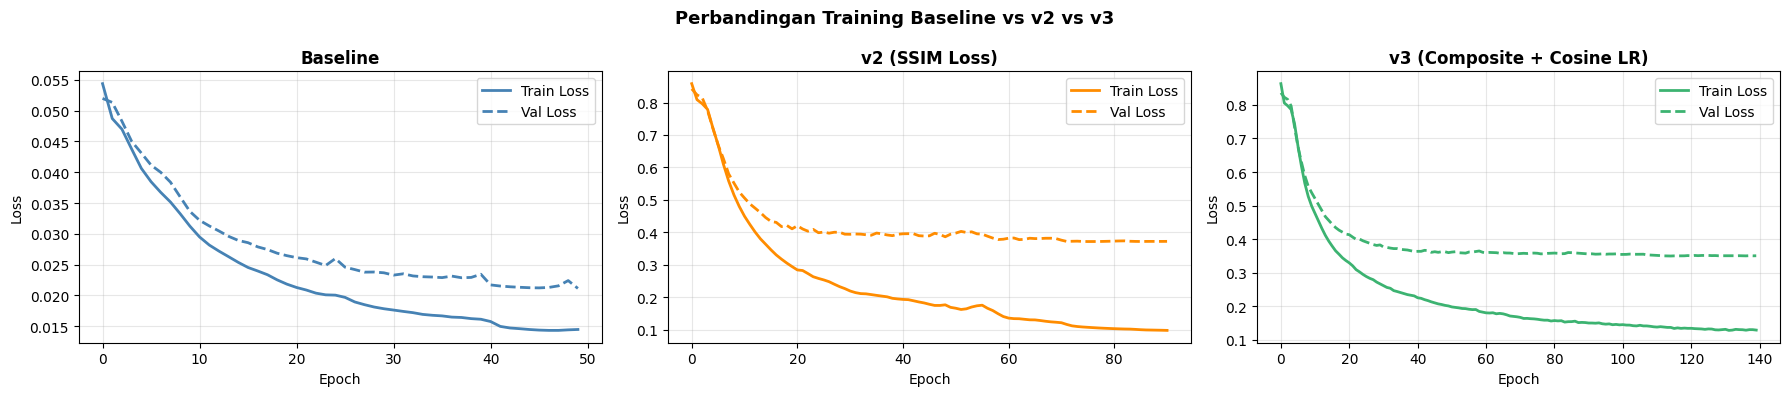

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Perbandingan Training Baseline vs v2 vs v3",
             fontsize=13, fontweight="bold")

for ax, hist, label, color in zip(
    axes,
    [history, history_v2, history_v3],
    ["Baseline", "v2 (SSIM Loss)", "v3 (Composite + Cosine LR)"],
    ["steelblue", "darkorange", "mediumseagreen"]
):
    ax.plot(hist.history["loss"],     color=color, lw=2, label="Train Loss")
    ax.plot(hist.history["val_loss"], color=color, lw=2, linestyle="--", label="Val Loss")
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_history_comparison.png", dpi=120, bbox_inches="tight")
plt.show()




Terlihat bahwa v3 memiliki penurunan loss yang paling stabil dan menghasilkan validation loss terendah dibanding baseline maupun v2.

### Visualisasi Rekonstruksi 3 Model

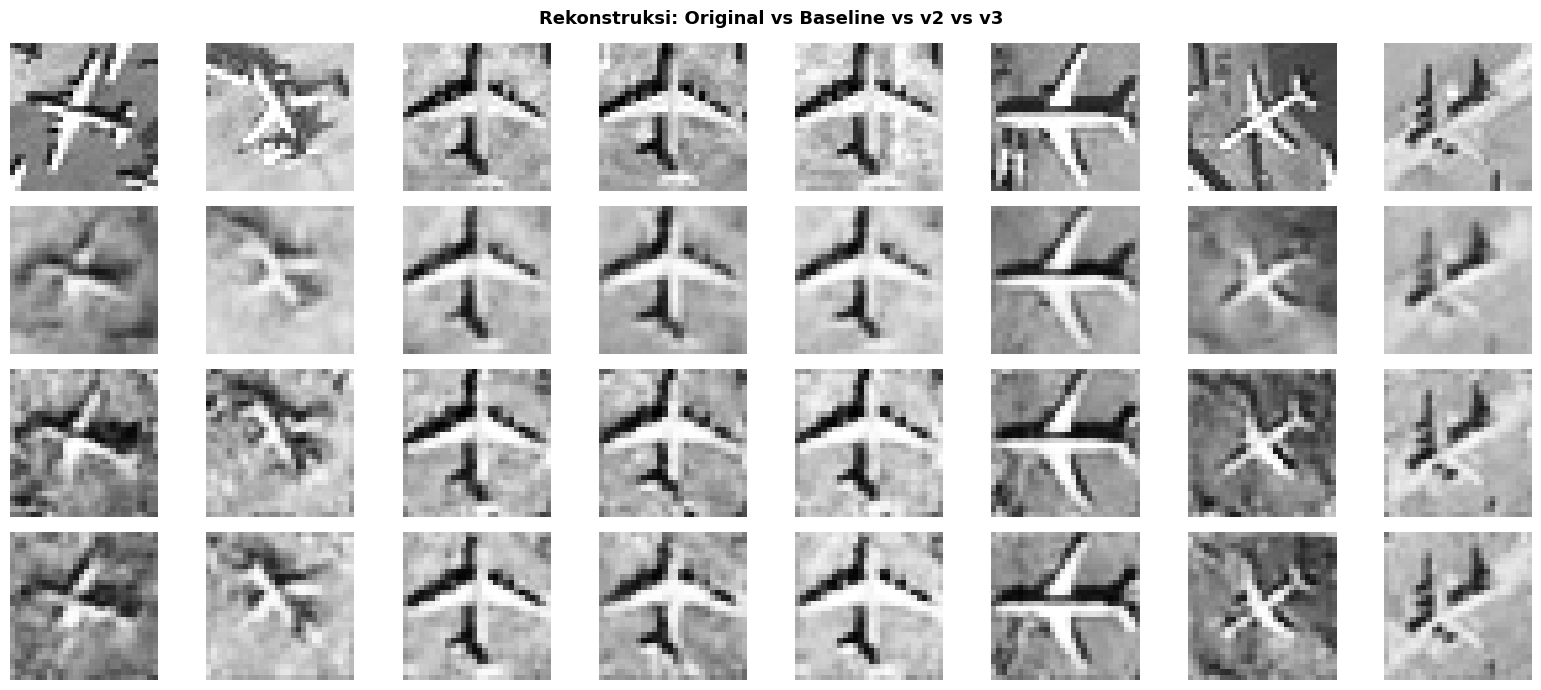

In [ ]:
N_SHOW = 8
fig, axes = plt.subplots(4, N_SHOW, figsize=(16, 7))
fig.suptitle("Rekonstruksi: Original vs Baseline vs v2 vs v3",
             fontsize=13, fontweight="bold")

row_labels = [
    ("Original",          "black"),
    (f"Baseline  (SSIM={ssim_scores.mean():.4f})",    "steelblue"),
    (f"v2        (SSIM={ssim_scores_v2.mean():.4f})", "darkorange"),
    (f"v3 Final  (SSIM={ssim_scores_v3.mean():.4f})", "mediumseagreen"),
]
recons = [X_test, X_test_reconstructed, X_test_recon_v2, X_test_recon_v3]

for row_idx, ((label, color), recon) in enumerate(zip(row_labels, recons)):
    for col_idx in range(N_SHOW):
        ax = axes[row_idx, col_idx]
        ax.imshow(recon[col_idx].squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        if col_idx == 0:
            ax.set_ylabel(label, color=color, fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("reconstruction_3models.png", dpi=120, bbox_inches="tight")
plt.show()

### Evaluasi akhir

In [ ]:
test_mse_v3 = float(tf.reduce_mean(tf.square(X_test - X_test_recon_v3)).numpy())

best_model  = max(
    [("Baseline", ssim_scores.mean()),
     ("v2", ssim_scores_v2.mean()),
     ("v3", ssim_scores_v3.mean())],
    key=lambda x: x[1]
)

print(f"  {'Model':<30}  {'Mean SSIM':>10}  {'Std SSIM':>10}  {'Test MSE':>10}")
print(f"  {'Baseline':<30}  {ssim_scores.mean():>10.4f}  {ssim_scores.std():>10.4f}  {float(tf.reduce_mean(tf.square(X_test - X_test_reconstructed)).numpy()):>10.6f}")
print(f"  {'v2':<30}  {ssim_scores_v2.mean():>10.4f}  {ssim_scores_v2.std():>10.4f}  {float(tf.reduce_mean(tf.square(X_test - X_test_recon_v2)).numpy()):>10.6f}")
print(f"  {'v3':<30}  {ssim_scores_v3.mean():>10.4f}  {ssim_scores_v3.std():>10.4f}  {test_mse_v3:>10.6f}")

print(f"\n Model terbaik : {best_model[0]}  (Mean SSIM = {best_model[1]:.4f})")

  Model                            Mean SSIM    Std SSIM    Test MSE
  Baseline (2b)                       0.5811      0.1610    0.020326
  v2  — SSIM Loss                     0.5919      0.1647    0.030185
  v3  — Tuned (Final, 2c)             0.6123      0.1515    0.027088

 Model terbaik : v3 — Tuned (Final, 2c)  (Mean SSIM = 0.6123)


Alasan Modifikasi Arsitektur Lebih Baik (v2 vs Baseline)
1. Filter Conv2D ditingkatkan dari 32 menjadi 64, sehingga encoder dapat menangkap fitur gambar yang lebih beragam sebelum proses kompresi.
2. Ditambahkan Dense 256 neuron sebelum latent layer agar proses pembentukan representasi 128 dimensi menjadi lebih terstruktur.
3. L2 Regularization (1e-5) membantu mengurangi overfitting, terutama karena jumlah data training relatif sedikit.
4. SSIM Loss menggantikan MSE, sehingga model belajar mempertahankan struktur, kontras, dan luminansi gambar, bukan hanya mengecilkan selisih nilai piksel.

Alasan Hyperparameter Tuning Lebih Baik (v3 vs v2)
1. Learning rate menggunakan Cosine Decay, sehingga update parameter besar dilakukan di awal training dan semakin halus di akhir training. Hal ini membantu model mencapai konvergensi yang lebih baik.
2. Batch size diperkecil dari 64 menjadi 32, sehingga update gradient lebih sering dan proses pembelajaran menjadi lebih detail.
3. Dropout 5% pada encoder membuat representasi latent lebih robust dan membantu mengurangi overfitting.
4. Jumlah epoch ditambah menjadi 150, sehingga model memiliki kesempatan belajar lebih lama. Namun dengan EarlyStopping, training tetap berhenti ketika performa validasi sudah tidak meningkat lagi sehingga waktu training tetap efisien.